# HDBSCAN

В этом ноутбуке посмотрим:

- чем **HDBSCAN** отличается от **DBSCAN**;
- почему HDBSCAN лучше работает с кластерами **разной плотности**;
- параметры `min_cluster_size` и `min_samples`;
- как модель определяет **шум**;
- метрики качества: **Silhouette**, **Davies–Bouldin**, **Calinski–Harabasz**.

## 1. Импорт зависимостей

In [12]:
import numpy as np
import pandas as pd
import hdbscan
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs, make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

np.random.seed(42)
plt.rcParams["figure.figsize"] = (7, 5)

## 2. Чем HDBSCAN отличается от DBSCAN

**Главная идея:** DBSCAN ищет области плотности выше одного порога `eps`. HDBSCAN строит **иерархию плотностей** и автоматически выбирает наиболее **стабильные** кластеры — поэтому ему не нужен `eps`.

## 3. Генерируем данные с кластерами разной плотности

Сделаем смесь: плотный маленький кластер, рыхлый большой и средний — плюс немного шума.

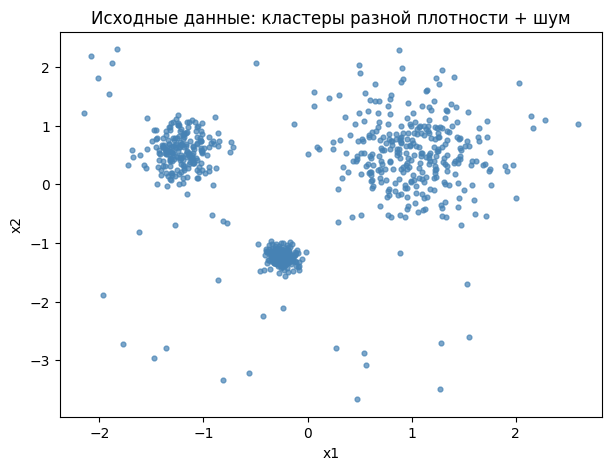

In [13]:
X1, _ = make_blobs(n_samples=200, centers=[[0, 0]],   cluster_std=0.25, random_state=1)
X2, _ = make_blobs(n_samples=300, centers=[[4, 4]],   cluster_std=1.20, random_state=2)
X3, _ = make_blobs(n_samples=200, centers=[[-3, 4]],  cluster_std=0.55, random_state=3)
noise = np.random.uniform(low=-6, high=8, size=(40, 2))

X = np.vstack([X1, X2, X3, noise])
X = StandardScaler().fit_transform(X)

plt.scatter(X[:, 0], X[:, 1], s=12, c="steelblue", alpha=0.7)
plt.title("Исходные данные: кластеры разной плотности + шум")
plt.xlabel("x1"); plt.ylabel("x2")
plt.show()

## 4. DBSCAN — один порог плотности на всех

DBSCAN c одним `eps` плохо ловит одновременно **плотный** и **рыхлый** кластеры: либо склеит, либо разорвёт.

DBSCAN: кластеров = 3, шумовых точек = 48


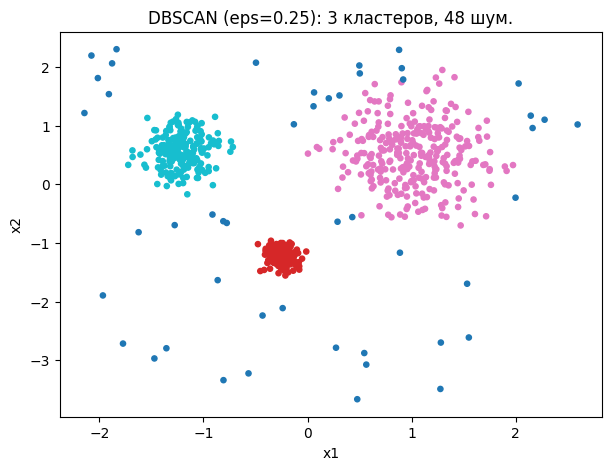

In [3]:
dbscan = DBSCAN(eps=0.25, min_samples=5).fit(X)
labels_db = dbscan.labels_

n_clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise_db = (labels_db == -1).sum()
print(f"DBSCAN: кластеров = {n_clusters_db}, шумовых точек = {n_noise_db}")

plt.scatter(X[:, 0], X[:, 1], c=labels_db, cmap="tab10", s=14)
plt.title(f"DBSCAN (eps=0.25): {n_clusters_db} кластеров, {n_noise_db} шум.")
plt.xlabel("x1"); plt.ylabel("x2")
plt.show()

## 5. HDBSCAN — адаптируется к разной плотности

HDBSCAN сам находит кластеры разного размера и плотности. Параметров всего два:

- **`min_cluster_size`** — минимальный размер группы, чтобы её считать кластером (а не шумом).
- **`min_samples`** — насколько «консервативно» определяется плотность (чем больше, тем больше точек уйдёт в шум).

HDBSCAN: кластеров = 3, шумовых точек = 27


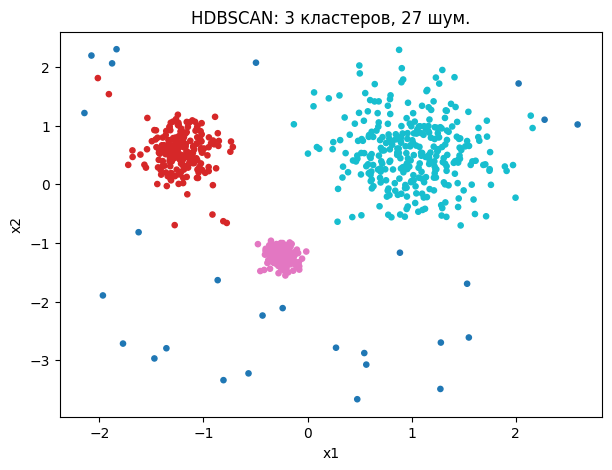

In [4]:
clusterer = hdbscan.HDBSCAN(min_cluster_size=20, min_samples=5)
labels_h = clusterer.fit_predict(X)

n_clusters_h = len(set(labels_h)) - (1 if -1 in labels_h else 0)
n_noise_h = (labels_h == -1).sum()
print(f"HDBSCAN: кластеров = {n_clusters_h}, шумовых точек = {n_noise_h}")

plt.scatter(X[:, 0], X[:, 1], c=labels_h, cmap="tab10", s=14)
plt.title(f"HDBSCAN: {n_clusters_h} кластеров, {n_noise_h} шум.")
plt.xlabel("x1"); plt.ylabel("x2")
plt.show()

## 6. DBSCAN vs HDBSCAN

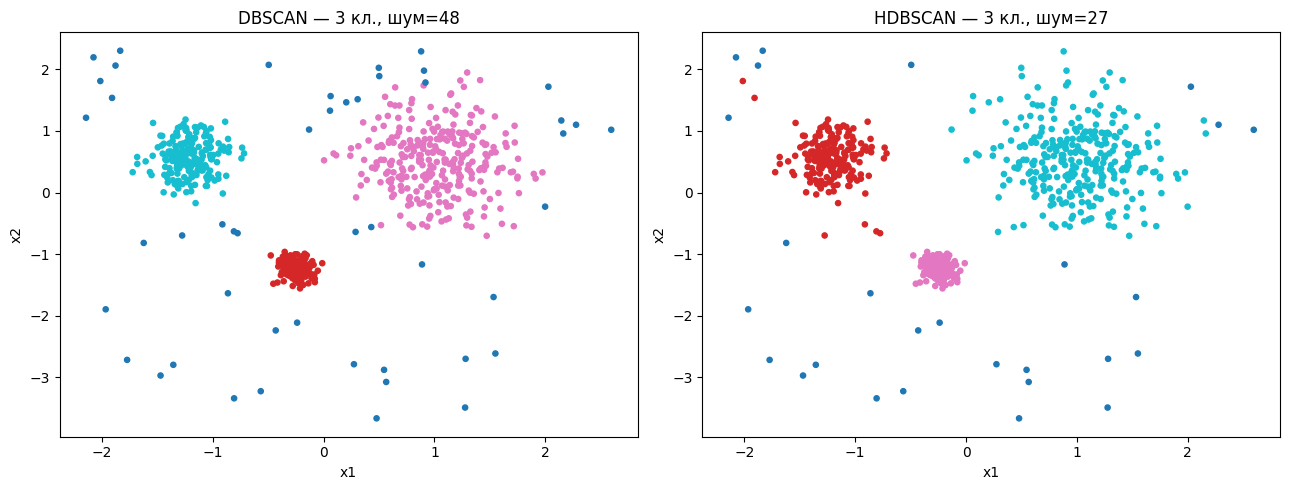

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(X[:, 0], X[:, 1], c=labels_db, cmap="tab10", s=14)
axes[0].set_title(f"DBSCAN — {n_clusters_db} кл., шум={n_noise_db}")

axes[1].scatter(X[:, 0], X[:, 1], c=labels_h, cmap="tab10", s=14)
axes[1].set_title(f"HDBSCAN — {n_clusters_h} кл., шум={n_noise_h}")

for ax in axes:
    ax.set_xlabel("x1"); ax.set_ylabel("x2")
plt.tight_layout()
plt.show()

## 7. Как модель определяет шум

В обоих алгоритмах шумовая метка — это **`-1`**. Подсветим такие точки красным.

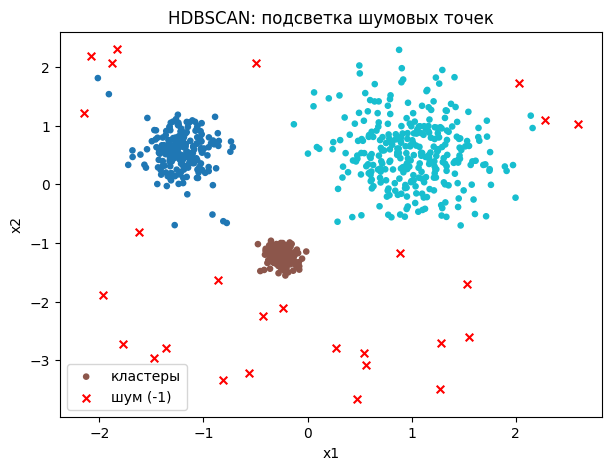

In [6]:
labels_show = labels_h
title_alg   = "HDBSCAN"

mask_noise = labels_show == -1

plt.scatter(X[~mask_noise, 0], X[~mask_noise, 1],
            c=labels_show[~mask_noise], cmap="tab10", s=14, label="кластеры")
plt.scatter(X[mask_noise, 0], X[mask_noise, 1],
            c="red", s=30, marker="x", label="шум (-1)")
plt.title(f"{title_alg}: подсветка шумовых точек")
plt.legend(); plt.xlabel("x1"); plt.ylabel("x2")
plt.show()

## 8. Влияние `min_cluster_size` и `min_samples`

Пробежимся по нескольким значениям и посмотрим, как меняется результат.

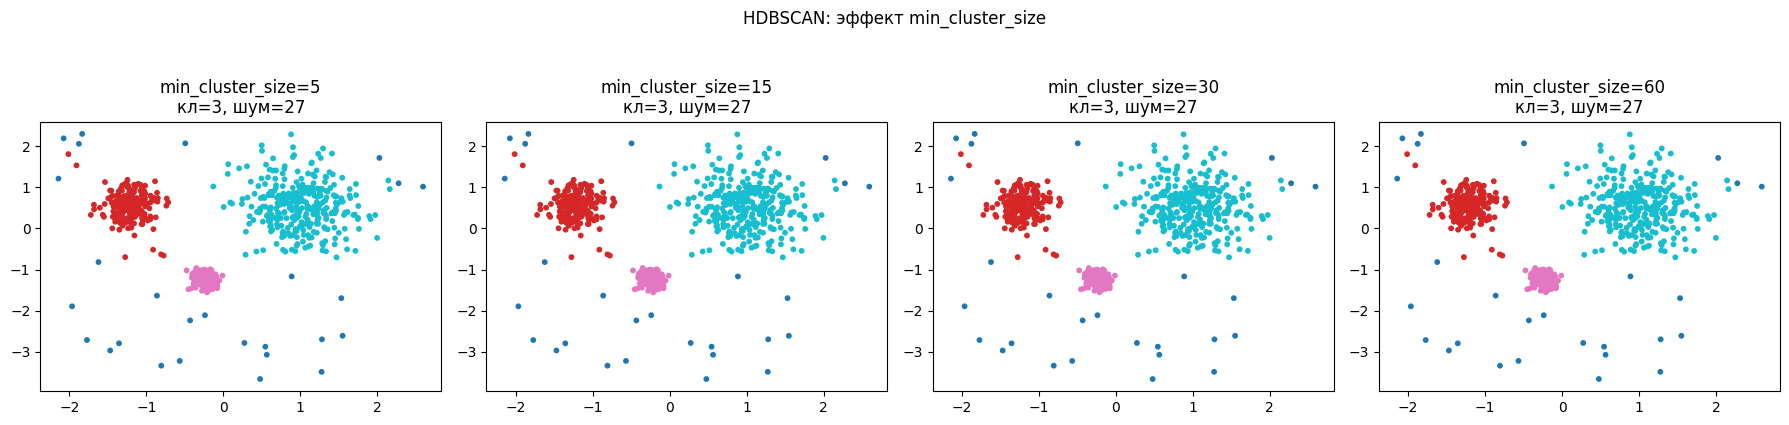

In [7]:
sizes = [5, 15, 30, 60]
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, s in zip(axes, sizes):
    lab = hdbscan.HDBSCAN(min_cluster_size=s, min_samples=5).fit_predict(X)
    n_cl = len(set(lab)) - (1 if -1 in lab else 0)
    n_ns = (lab == -1).sum()
    ax.scatter(X[:, 0], X[:, 1], c=lab, cmap="tab10", s=10)
    ax.set_title(f"min_cluster_size={s}\nкл={n_cl}, шум={n_ns}")
plt.suptitle("HDBSCAN: эффект min_cluster_size", y=1.05)
plt.tight_layout(); plt.show()

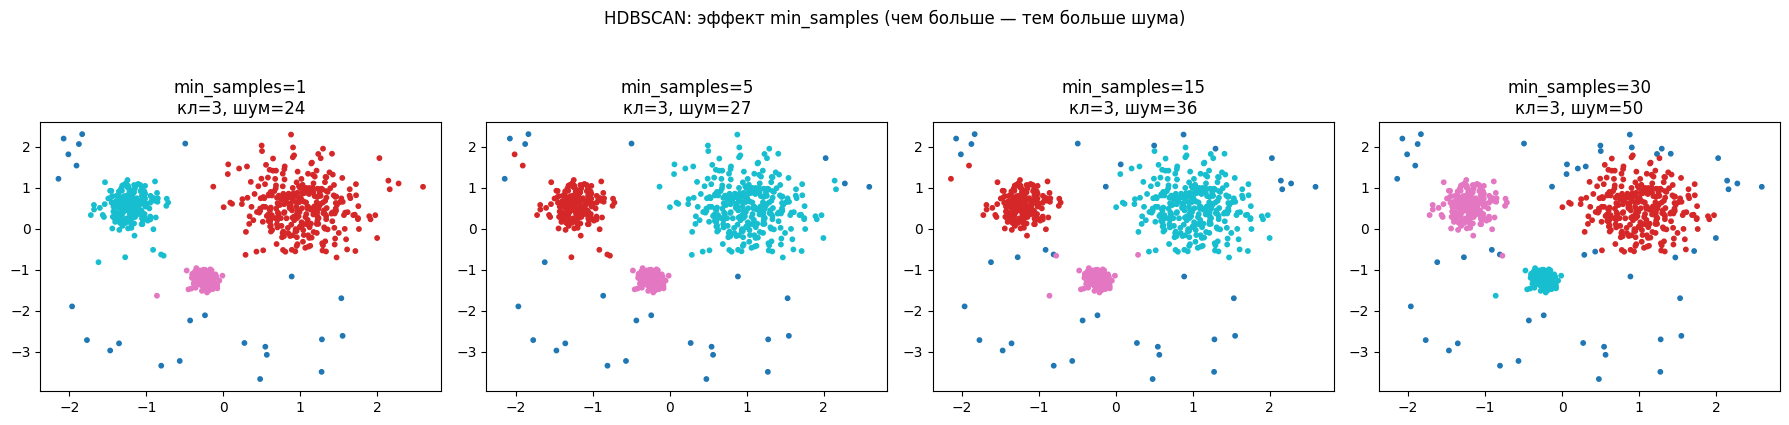

In [8]:
samples = [1, 5, 15, 30]
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, ms in zip(axes, samples):
    lab = hdbscan.HDBSCAN(min_cluster_size=20, min_samples=ms).fit_predict(X)
    n_cl = len(set(lab)) - (1 if -1 in lab else 0)
    n_ns = (lab == -1).sum()
    ax.scatter(X[:, 0], X[:, 1], c=lab, cmap="tab10", s=10)
    ax.set_title(f"min_samples={ms}\nкл={n_cl}, шум={n_ns}")
plt.suptitle("HDBSCAN: эффект min_samples (чем больше — тем больше шума)", y=1.05)
plt.tight_layout(); plt.show()

## 9. Вероятности принадлежности к кластеру

У HDBSCAN есть атрибут `probabilities_` — насколько точка «уверенно» принадлежит своему кластеру (0 = шум/край, 1 = ядро).

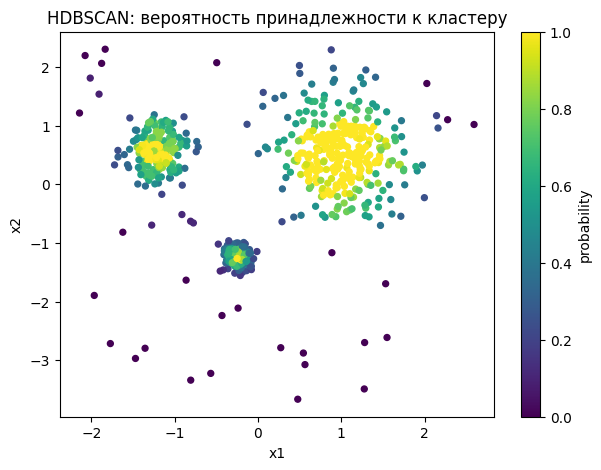

In [9]:
probs = clusterer.probabilities_
sc = plt.scatter(X[:, 0], X[:, 1], c=probs, cmap="viridis", s=18)
plt.colorbar(sc, label="probability")
plt.title("HDBSCAN: вероятность принадлежности к кластеру")
plt.xlabel("x1"); plt.ylabel("x2")
plt.show()

## 10. Метрики качества кластеризации

- **Silhouette Score** — от -1 до 1, чем выше — тем лучше.
- **Davies–Bouldin** — чем **ниже**, тем лучше.
- **Calinski–Harabasz** — чем **выше**, тем лучше.

Шумовые точки (`-1`) для метрик исключаем.

In [10]:
def cluster_metrics(X, labels, name):
    mask = labels != -1
    if mask.sum() < 2 or len(set(labels[mask])) < 2:
        return {"algo": name, "silhouette": np.nan, "davies_bouldin": np.nan, "calinski_harabasz": np.nan}
    return {
        "algo": name,
        "silhouette":        silhouette_score(X[mask], labels[mask]),
        "davies_bouldin":    davies_bouldin_score(X[mask], labels[mask]),
        "calinski_harabasz": calinski_harabasz_score(X[mask], labels[mask]),
    }

rows = [cluster_metrics(X, labels_db, "DBSCAN")]
rows.append(cluster_metrics(X, labels_h, "HDBSCAN"))

df_metrics = pd.DataFrame(rows).round(3)
df_metrics

,algo,silhouette,davies_bouldin,calinski_harabasz
0,DBSCAN,0.750,0.359,2592.049
1,HDBSCAN,0.723,0.385,2167.086


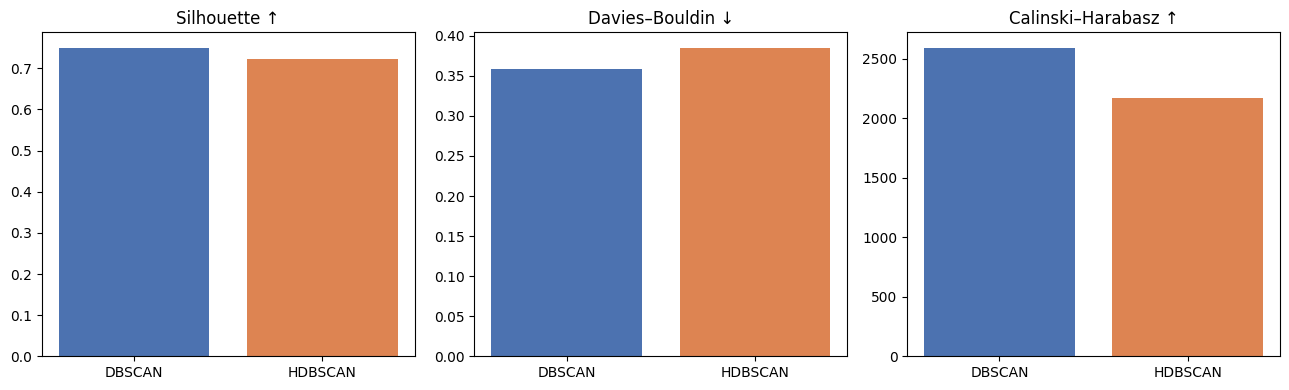

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
metrics = ["silhouette", "davies_bouldin", "calinski_harabasz"]
titles  = ["Silhouette ↑", "Davies–Bouldin ↓", "Calinski–Harabasz ↑"]
colors  = ["#4C72B0", "#DD8452"]
for ax, m, t in zip(axes, metrics, titles):
    ax.bar(df_metrics["algo"], df_metrics[m], color=colors[:len(df_metrics)])
    ax.set_title(t)
plt.tight_layout(); plt.show()

#**Общий итог:**

- **DBSCAN** требует подбирать `eps` и плохо справляется с **разной плотностью**.
- **HDBSCAN** строит иерархию плотностей и сам выбирает стабильные кластеры — параметр `eps` не нужен.
- **`min_cluster_size`** контролирует минимальный размер кластера, **`min_samples`** — насколько строго отделять шум.
- Шум — точки с меткой **`-1`** (для HDBSCAN ещё и с низкой `probability`).
- На данных с разной плотностью HDBSCAN обычно даёт **выше Silhouette / Calinski-Harabasz** и **ниже Davies-Bouldin**, чем DBSCAN с одним `eps`.